In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.signal import butter, filtfilt

In [2]:
df_train_from_scratch = pd.read_csv("../results/loss_from_scratch.csv")
df_train_base_model = pd.read_csv("../results/loss_base_model.csv")
df_train_finetuned_5k = pd.read_csv("../results/loss_finetuned_from_5k.csv")
df_train_finetuned_15k = pd.read_csv("../results/loss_finetuned_from_15k.csv")
df_train_finetuned_30k = pd.read_csv("../results/loss_finetuned_from_30k.csv")
df_train_finetuned_RI = pd.read_csv("../results/loss_finetuned_from_RI.csv")

In [3]:
df_mean_from_scratch = pd.read_csv("../results/mean_loss_from_scratch.csv")
df_mean_base_model = pd.read_csv("../results/mean_loss_base_model.csv")
df_mean_finetuned_5k = pd.read_csv("../results/mean_loss_finetuned_from_5k.csv")
df_mean_finetuned_15k = pd.read_csv("../results/mean_loss_finetuned_from_15k.csv")
df_mean_finetuned_30k = pd.read_csv("../results/mean_loss_finetuned_from_30k.csv")
df_mean_finetuned_RI = pd.read_csv("../results/mean_loss_finetuned_from_RI.csv")

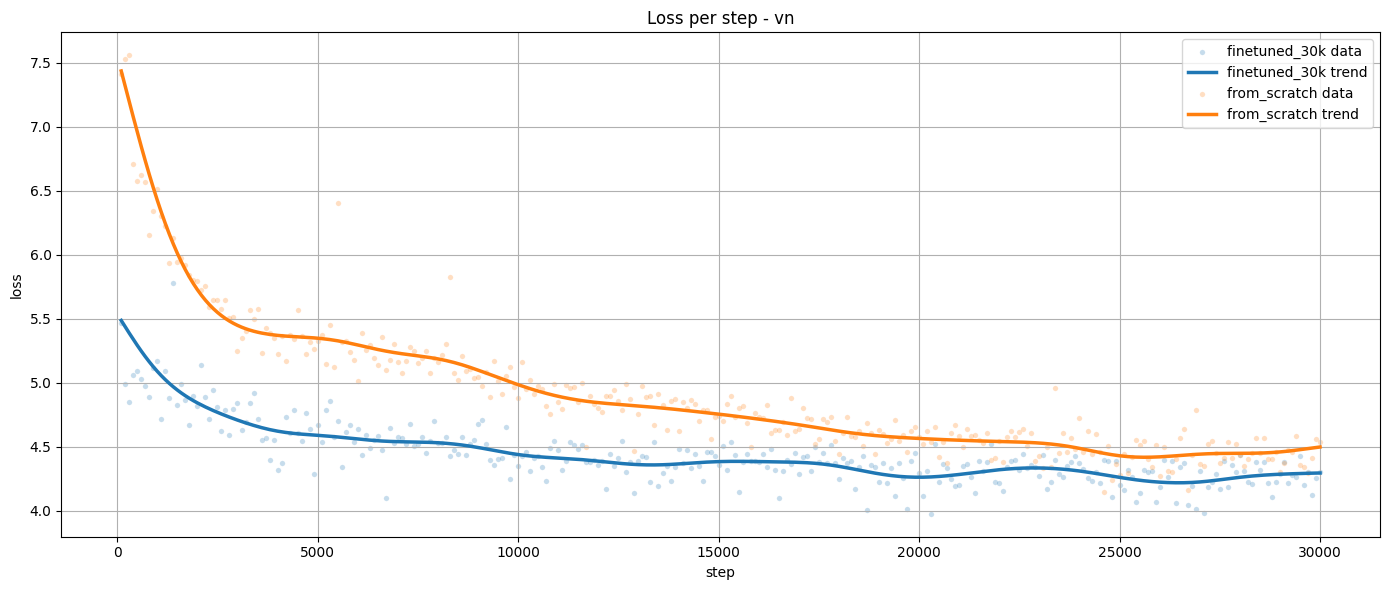

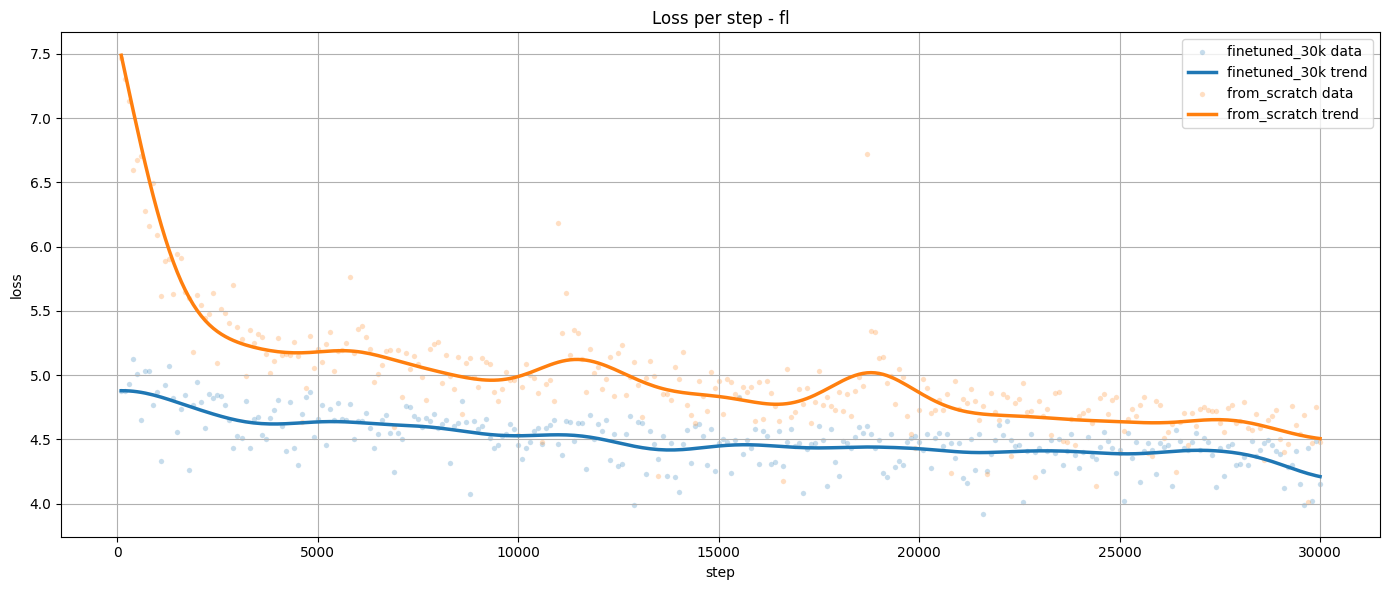

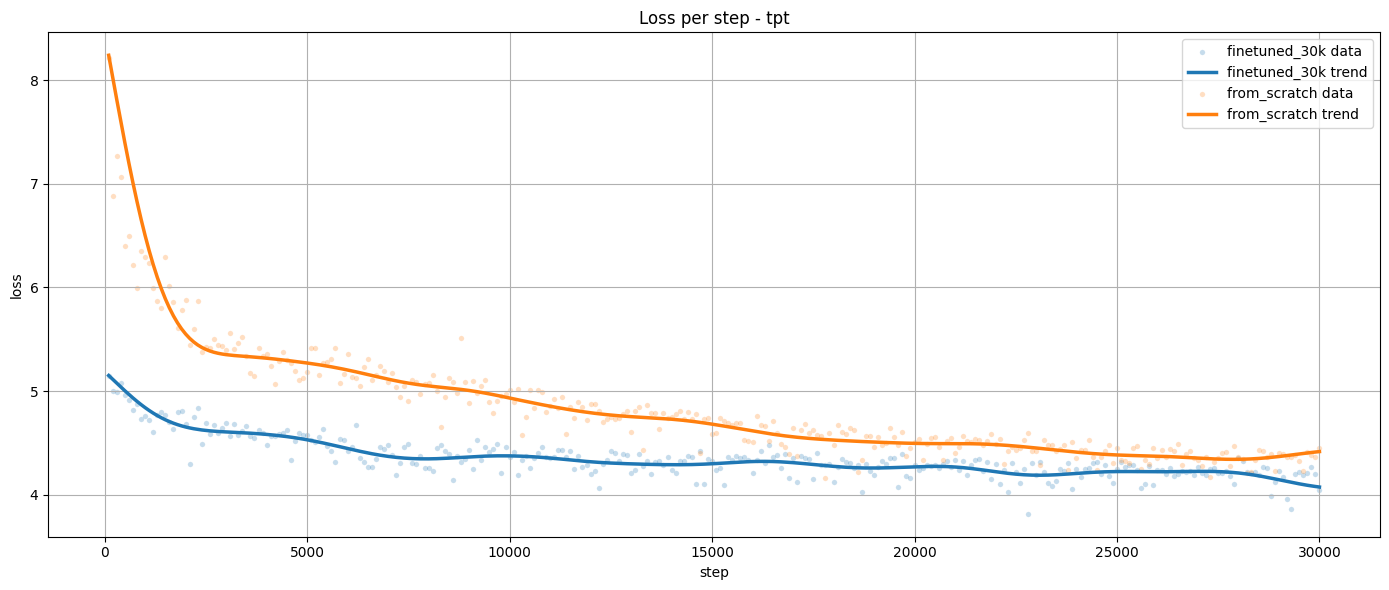

In [4]:
for d in [df_train_from_scratch, df_train_finetuned_5k, df_train_finetuned_15k, 
          df_train_finetuned_30k, df_train_finetuned_RI, df_train_base_model]:
    d.columns = d.columns.str.strip()

instruments = ["vn", "fl", "tpt"]
runs = [
    ("from_scratch", df_train_from_scratch),
    # ("finetuned_5k", df_train_finetuned_5k),
    # ("finetuned_15k", df_train_finetuned_15k),
    ("finetuned_30k", df_train_finetuned_30k),
    # ("finetuned_RI", df_train_finetuned_RI),
    ("base_model", df_train_base_model),
]

for instrument in instruments:
    rows = []

    for run_name, d in runs:
        if "Step" not in d.columns:
            continue

        col = f"{instrument} - loss"
        if col in d.columns:
            rows.append(pd.DataFrame({
                "Step": d["Step"],
                "loss": d[col],
                "series": run_name,
            }))

    if not rows:
        print(f"No valid loss columns found for {instrument}.")
        continue

    plot_df = pd.concat(rows, ignore_index=True).dropna()

    plt.figure(figsize=(14, 6))
    ax = plt.gca()
    palette = sns.color_palette("tab10", n_colors=plot_df["series"].nunique())

    for color, (series_name, group) in zip(palette, plot_df.groupby("series")):
        group = group.sort_values("Step")

        sns.scatterplot(
            data=group,
            x="Step",
            y="loss",
            ax=ax,
            color=color,
            alpha=0.25,
            s=15,
            label=f"{series_name} data",
        )

        y = group["loss"].to_numpy()

        # low-pass filter on uniform samples
        b, a = butter(N=3, Wn=0.05, btype="low")
        smoothed_y = filtfilt(b, a, y)

        ax.plot(group["Step"], smoothed_y, color=color, lw=2.5, label=f"{series_name} trend")

    ax.set_title(f"Loss per step - {instrument}")
    ax.set_xlabel("step")
    ax.set_ylabel("loss")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

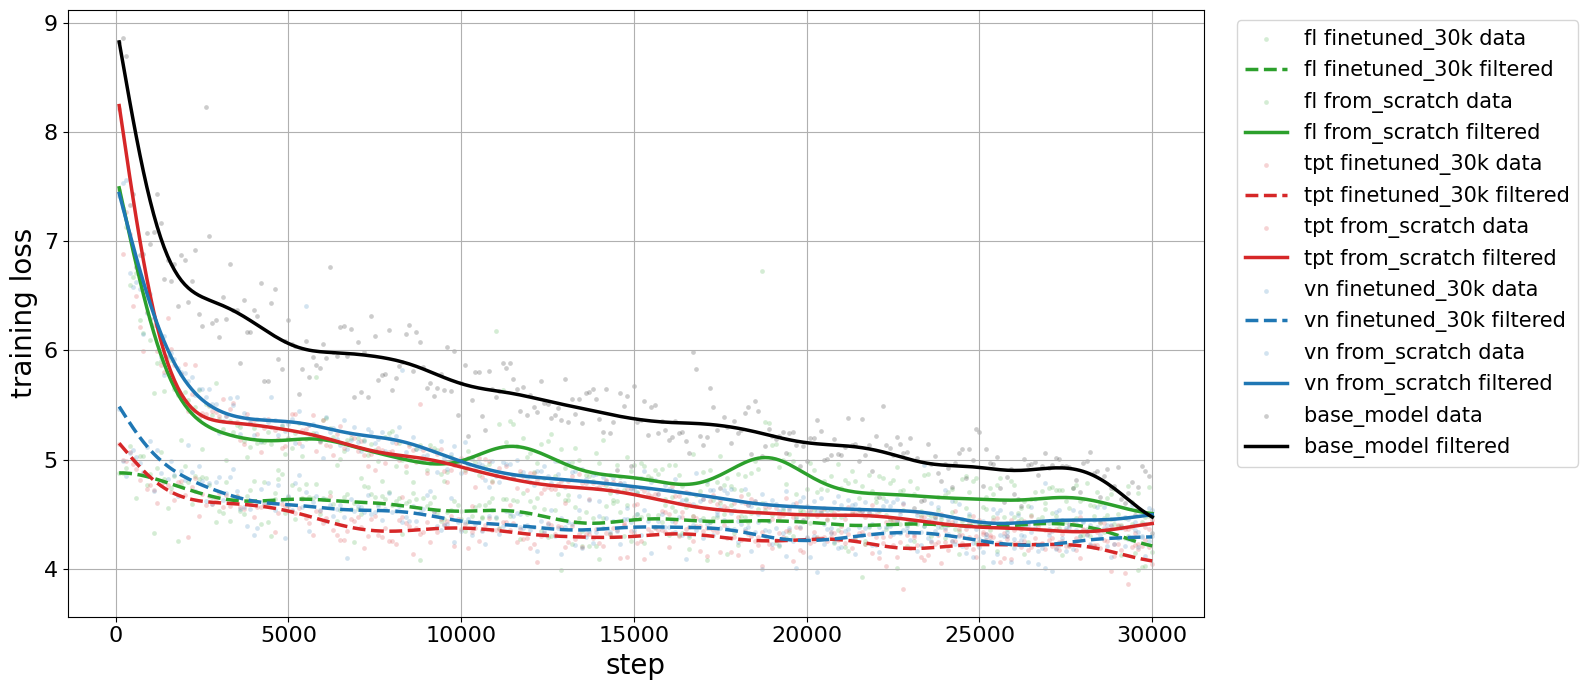

In [5]:
for d in [df_train_from_scratch, df_train_finetuned_5k, df_train_finetuned_15k, 
          df_train_finetuned_30k, df_train_finetuned_RI, df_train_base_model]:
    d.columns = d.columns.str.strip()

instruments = ["vn", "fl", "tpt"]

# per-instrument runs (unchanged)
instrument_runs = [
    ("from_scratch", df_train_from_scratch),
    # ("finetuned_5k", df_train_finetuned_5k),
    # ("finetuned_15k", df_train_finetuned_15k),
    ("finetuned_30k", df_train_finetuned_30k),
    # ("finetuned_RI", df_train_finetuned_RI),
]

# single-series runs — not split by instrument
single_runs = [
    ("base_model", df_train_base_model, "base_model - loss"),
]

instrument_colors = {
    "vn": "#1f77b4",   # blue
    "fl": "#2ca02c",   # green
    "tpt": "#d62728",  # red
}

run_styles = {
    "from_scratch": "-",
    "finetuned_30k": "--",
    "finetuned_15k": ":",
    "base_model": "-",
}

def smooth(y, N=3, Wn=0.05):
    if len(y) < 3 * max(N, 1) + 1:  # filtfilt's default padlen requirement
        return y  # too short to filter safely — fall back to raw
    b, a = butter(N=N, Wn=Wn, btype="low")
    return filtfilt(b, a, y)

rows = []
for run_name, d in instrument_runs:
    if "Step" not in d.columns:
        continue
    for instrument in instruments:
        col = f"{instrument} - loss"
        if col in d.columns:
            rows.append(pd.DataFrame({
                "Step": d["Step"],
                "loss": d[col],
                "instrument": instrument,
                "run": run_name,
                "series": f"{instrument} {run_name}",
            }))

plot_df = pd.concat(rows, ignore_index=True).dropna() if rows else pd.DataFrame()

plt.figure(figsize=(16, 7))
ax = plt.gca()

if not plot_df.empty:
    for (instrument, run_name), group in plot_df.groupby(["instrument", "run"]):
        group = group.sort_values("Step")
        color = instrument_colors.get(instrument, "gray")
        linestyle = run_styles.get(run_name, "-")

        sns.scatterplot(
            data=group, x="Step", y="loss", ax=ax,
            color=color, alpha=0.20, s=12,
            label=f"{instrument} {run_name} data",
        )
        smoothed_y = smooth(group["loss"].to_numpy())
        ax.plot(
            group["Step"], smoothed_y,
            color=color, linestyle=linestyle, lw=2.5,
            label=f"{instrument} {run_name} filtered",
        )

for run_name, d, col in single_runs:
    if "Step" not in d.columns or col not in d.columns:
        print(f"Skipping {run_name}: missing Step or '{col}' column. Found: {list(d.columns)}")
        continue
    g = d[["Step", col]].dropna().sort_values("Step")
    smoothed_y = smooth(g[col].to_numpy())

    sns.scatterplot(
        x=g["Step"], y=g[col], ax=ax,
        color="k", alpha=0.20, s=12,
        label=f"{run_name} data",
    )
    ax.plot(
        g["Step"], smoothed_y,
        color="k", linestyle=run_styles.get(run_name, "-"), lw=2.5,
        label=f"{run_name} filtered",
    )

ax.set_xlabel("step", fontsize=20)
ax.set_ylabel("training loss", fontsize=20)
ax.tick_params(axis="both", labelsize=16)
ax.grid(True)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=15)
plt.tight_layout()
plt.show()

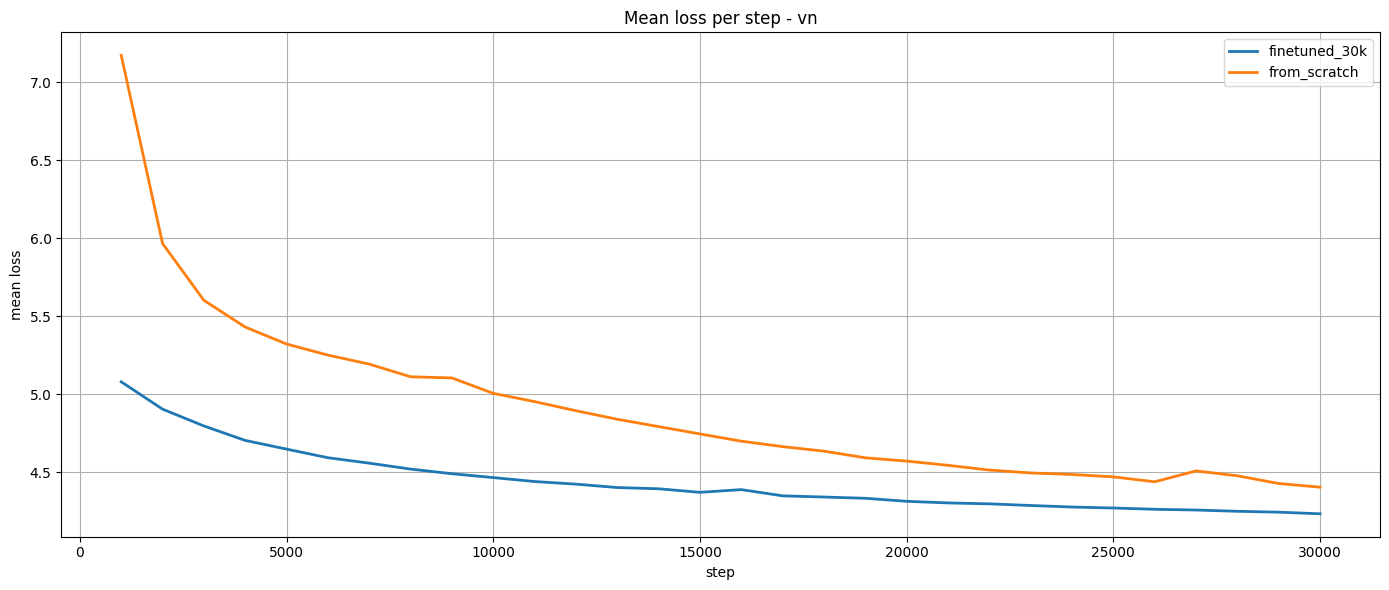

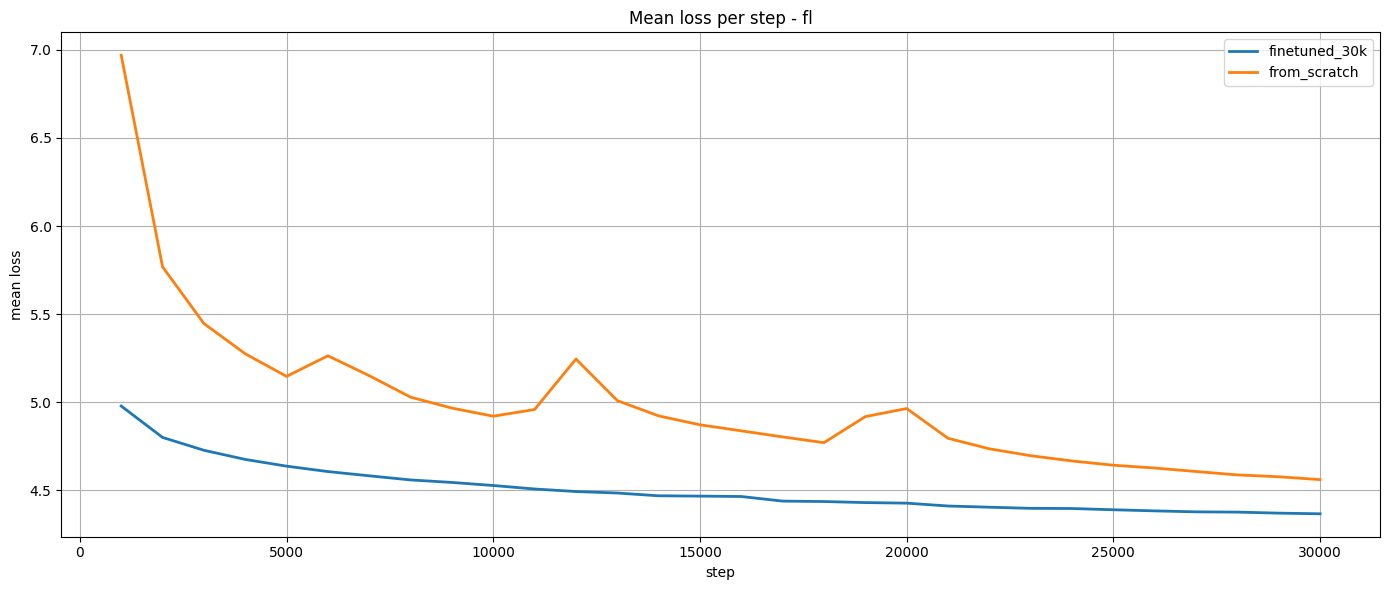

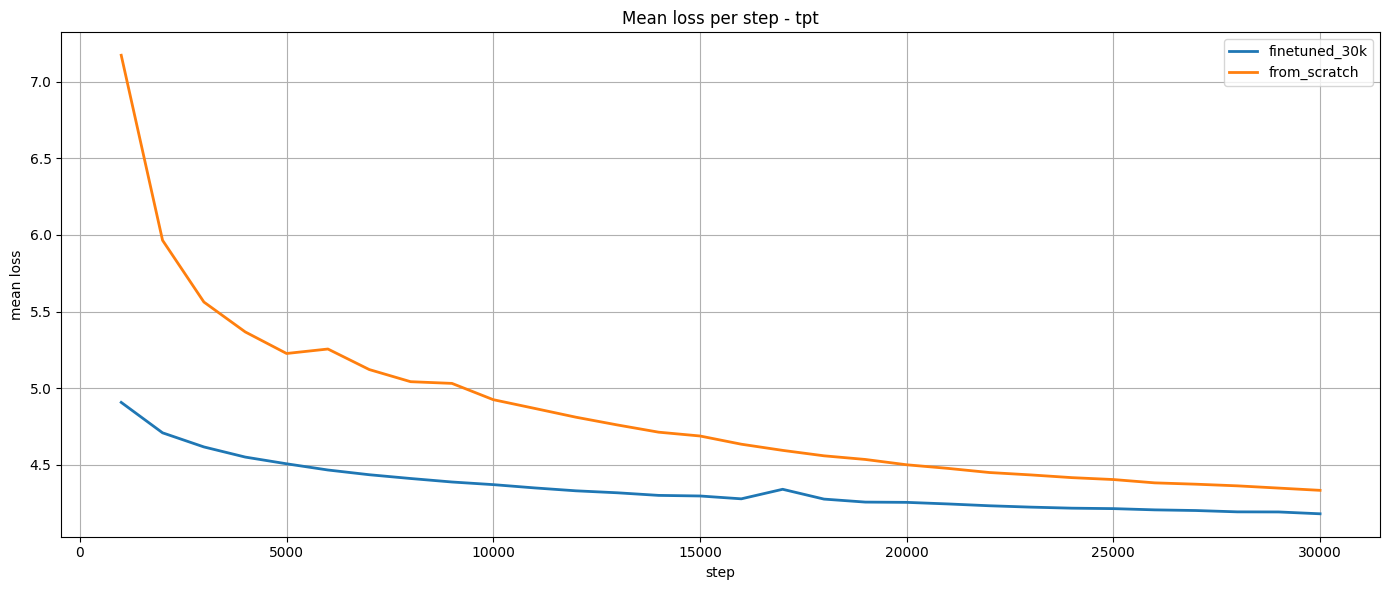

In [6]:
for d in [df_mean_from_scratch, df_mean_finetuned_5k, df_mean_finetuned_15k, 
          df_mean_finetuned_30k, df_mean_finetuned_RI, df_mean_base_model]:
    d.columns = d.columns.str.strip()

instruments = ["vn", "fl", "tpt"]
mean_runs = [
    ("from_scratch", df_mean_from_scratch),
    # ("finetuned_5k", df_mean_finetuned_5k),
    # ("finetuned_15k", df_mean_finetuned_15k),
    ("finetuned_30k", df_mean_finetuned_30k),
    # ("finetuned_RI", df_mean_finetuned_RI),
]

for instrument in instruments:
    rows = []

    for run_name, d in mean_runs:
        if "Step" not in d.columns:
            continue

        col = f"{instrument} - mean_loss"
        if col in d.columns:
            rows.append(pd.DataFrame({
                "Step": d["Step"],
                "mean_loss": d[col],
                "series": run_name,
            }))

    if not rows:
        print(f"No valid mean_loss columns found for {instrument}.")
        continue

    plot_df = pd.concat(rows, ignore_index=True).dropna()

    plt.figure(figsize=(14, 6))
    ax = plt.gca()
    palette = sns.color_palette("tab10", n_colors=plot_df["series"].nunique())

    for color, (series_name, group) in zip(palette, plot_df.groupby("series")):
        group = group.sort_values("Step")

        ax.plot(group["Step"], group["mean_loss"], color=color, lw=2, label=series_name)

    ax.set_title(f"Mean loss per step - {instrument}")
    ax.set_xlabel("step")
    ax.set_ylabel("mean loss")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

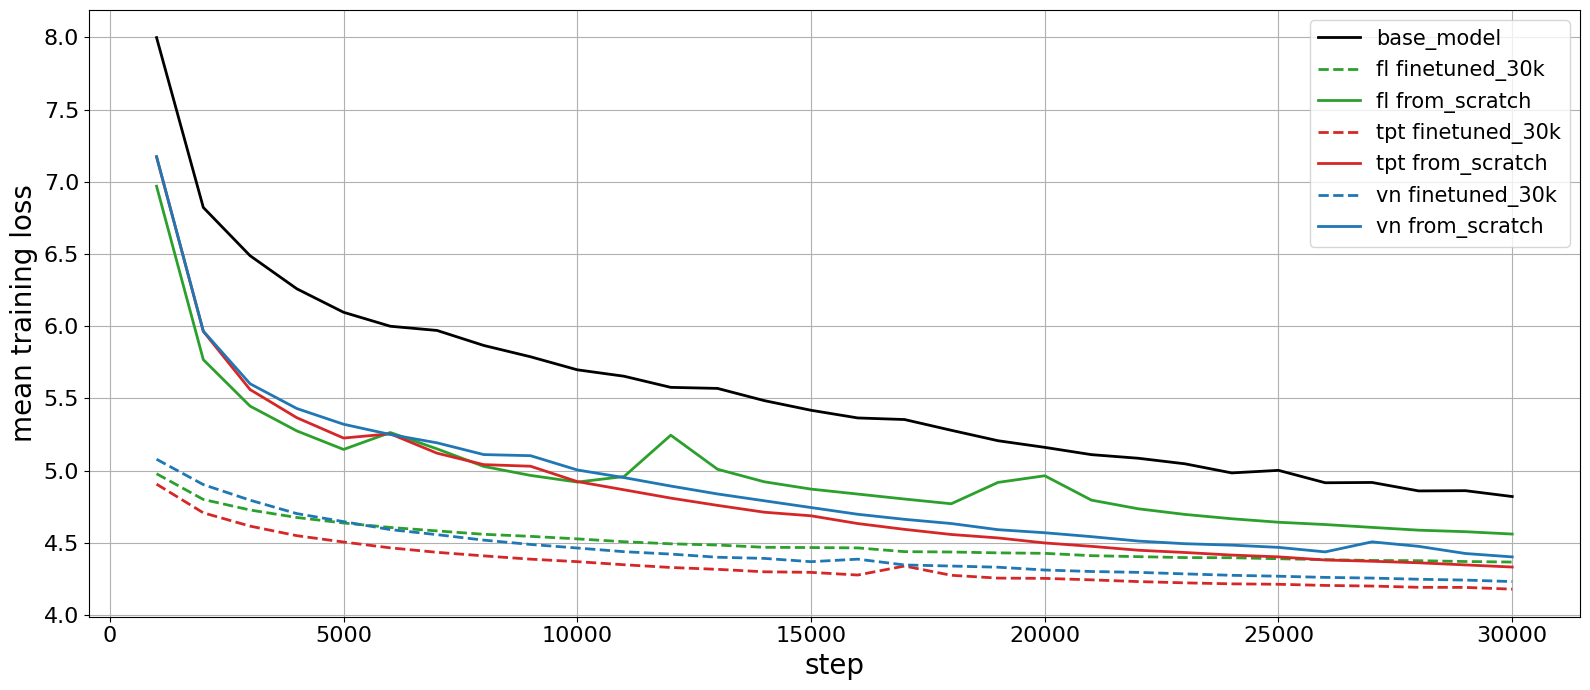

In [10]:
for d in [df_mean_from_scratch, df_mean_finetuned_5k, df_mean_finetuned_15k, 
          df_mean_finetuned_30k, df_mean_finetuned_RI, df_mean_base_model]:
    d.columns = d.columns.str.strip()

instruments = ["vn", "fl", "tpt"]
mean_runs = [
    ("from_scratch", df_mean_from_scratch),
    # ("finetuned_5k", df_mean_finetuned_5k),
    # ("finetuned_15k", df_mean_finetuned_15k),
    ("finetuned_30k", df_mean_finetuned_30k),
    # ("finetuned_RI", df_mean_finetuned_RI),
]

instrument_colors = {
    "vn": "#1f77b4",   # blue
    "fl": "#2ca02c",   # green
    "tpt": "#d62728",  # red
    "base_model": 'k'
}

run_styles = {
    "from_scratch": "-",
    "finetuned_30k": "--",
    "finetuned_15k": ":",
    "finetuned_5k": "-.",
}

rows = []
for run_name, d in mean_runs:
    if "Step" not in d.columns:
        continue

    for instrument in instruments:
        col = f"{instrument} - mean_loss"
        if col in d.columns:
            rows.append(pd.DataFrame({
                "Step": d["Step"],
                "mean_loss": d[col],
                "instrument": instrument,
                "run": run_name,
                "series": f"{instrument} {run_name}",
            }))

base_col = "base_model - mean_loss"
if "Step" in df_mean_base_model.columns and base_col in df_mean_base_model.columns:
    rows.append(pd.DataFrame({
        "Step": df_mean_base_model["Step"],
        "mean_loss": df_mean_base_model[base_col],
        "instrument": "base_model",
        "run": "base_model",
        "series": "base_model",
    }))

if not rows:
    print("No valid mean training loss columns found.")
else:
    plot_df = pd.concat(rows, ignore_index=True).dropna()

    plt.figure(figsize=(16, 7))
    ax = plt.gca()

    for (instrument, run_name), group in plot_df.groupby(["instrument", "run"]):
        group = group.sort_values("Step")
        color = instrument_colors.get(instrument, "gray")
        linestyle = run_styles.get(run_name, "-")

        ax.plot(
            group["Step"], group["mean_loss"],
            color=color,
            linestyle=linestyle,
            lw=2,
            label=f"{instrument} {run_name}" if instrument != "base_model" else "base_model"
        )

    ax.set_xlabel("step", fontsize=20)
    ax.set_ylabel("mean training loss", fontsize=20)
    ax.tick_params(axis="both", labelsize=16)
    ax.grid(True)
    ax.legend(loc="upper right", fontsize=15)
    plt.tight_layout()
    plt.show()